# Task 4: Time Series Analysis (Fedez vs. Fabri Fibra)


## Imports and Loading

In [468]:
import os
import warnings
from collections import Counter

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm

import librosa
import librosa.display

from sklearn.preprocessing import LabelEncoder, Normalizer
from sklearn.metrics import accuracy_score
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.preprocessing import Normalizer

from tslearn.clustering import TimeSeriesKMeans
from tslearn.preprocessing import TimeSeriesScalerMeanVariance, TimeSeriesResampler
from tslearn.shapelets import LearningShapelets

from transformers import ClapModel, ClapProcessor

from feature_extractor import FeatureExtractor
from utils import *

import umap
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import pairwise_distances

import torch
warnings.filterwarnings('ignore')

# Set plot style
plt.style.use('seaborn-v0_8-muted')

In [469]:

MP3_FOLDER = "/Users/lorenzoallegrini/Downloads/fedez_fibra"
DATASETS_FOLDER = "../datasets"

ARTIST_MAPPING = {
    "07024718": "Fedez",
    "25707984": "Fabri Fibra"
}

def get_artist_from_filename(filename):
    try:
        # Nota: La funzione lavora solo sul nome del file, non sul path intero
        artist_id = filename.split(' - ')[0].replace('ART', '')
        return ARTIST_MAPPING.get(artist_id, "Unknown")
    except:
        return "Unknown"


filenames = [f for f in os.listdir(MP3_FOLDER) if f.endswith('.mp3')]
print(f"Found {len(filenames)} MP3 files.")


fedez_files = [
    os.path.join(MP3_FOLDER, f)
    for f in filenames
    if get_artist_from_filename(f) == "Fedez"
]

fibra_files = [
    os.path.join(MP3_FOLDER, f)
    for f in filenames
    if get_artist_from_filename(f) == "Fabri Fibra"
]

all_files = fedez_files[:15] + fibra_files[:15]



Found 454 MP3 files.


In [470]:
import librosa
import numpy as np
from tqdm import tqdm
TARGET_SR = 24000

all_lengths = []
for file_path in tqdm(all_files, desc="Calcolando lunghezze"):
    try:
        y, _ = librosa.load(file_path, sr=TARGET_SR)
        all_lengths.append(len(y))
    except Exception as e:
        print(f"Errore leggendo {file_path}: {e}")

all_lengths = np.array(all_lengths)
target_length_samples = int(np.percentile(all_lengths, 95))
target_length_seconds = target_length_samples / TARGET_SR


Calcolando lunghezze: 100%|██████████| 30/30 [00:07<00:00,  4.22it/s]


In [471]:
print(f"\n--- Statistiche lunghezze audio ---")
print(f"Min: {all_lengths.min() / TARGET_SR:.2f}s ({all_lengths.min()} samples)")
print(f"Max: {all_lengths.max() / TARGET_SR:.2f}s ({all_lengths.max()} samples)")
print(f"Average: {all_lengths.mean() / TARGET_SR:.2f}s")
print(f"Median: {np.median(all_lengths) / TARGET_SR:.2f}s")


--- Statistiche lunghezze audio ---
Min: 124.02s (2976427 samples)
Max: 313.92s (7534080 samples)
Average: 206.00s
Median: 198.73s


### visualization of the first songs

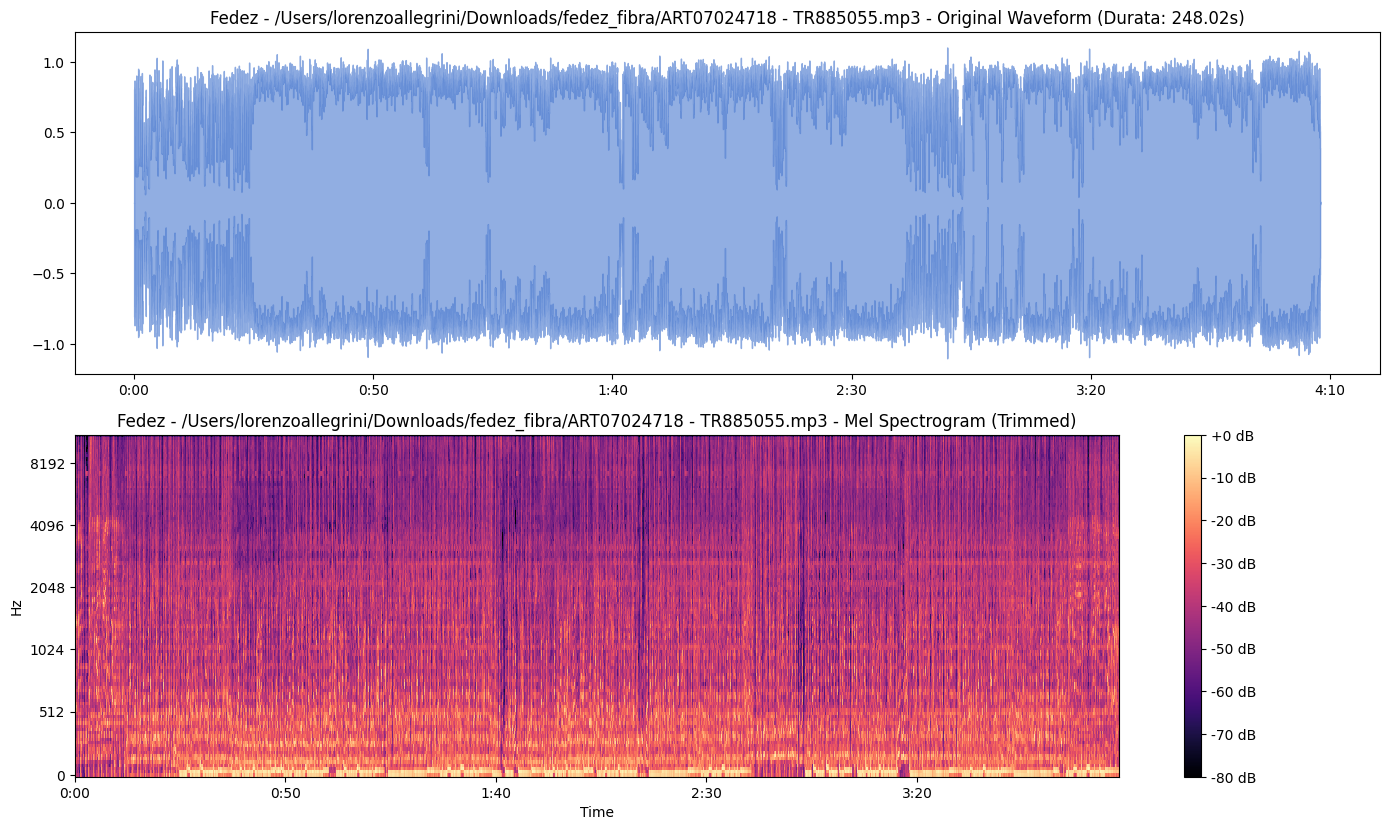

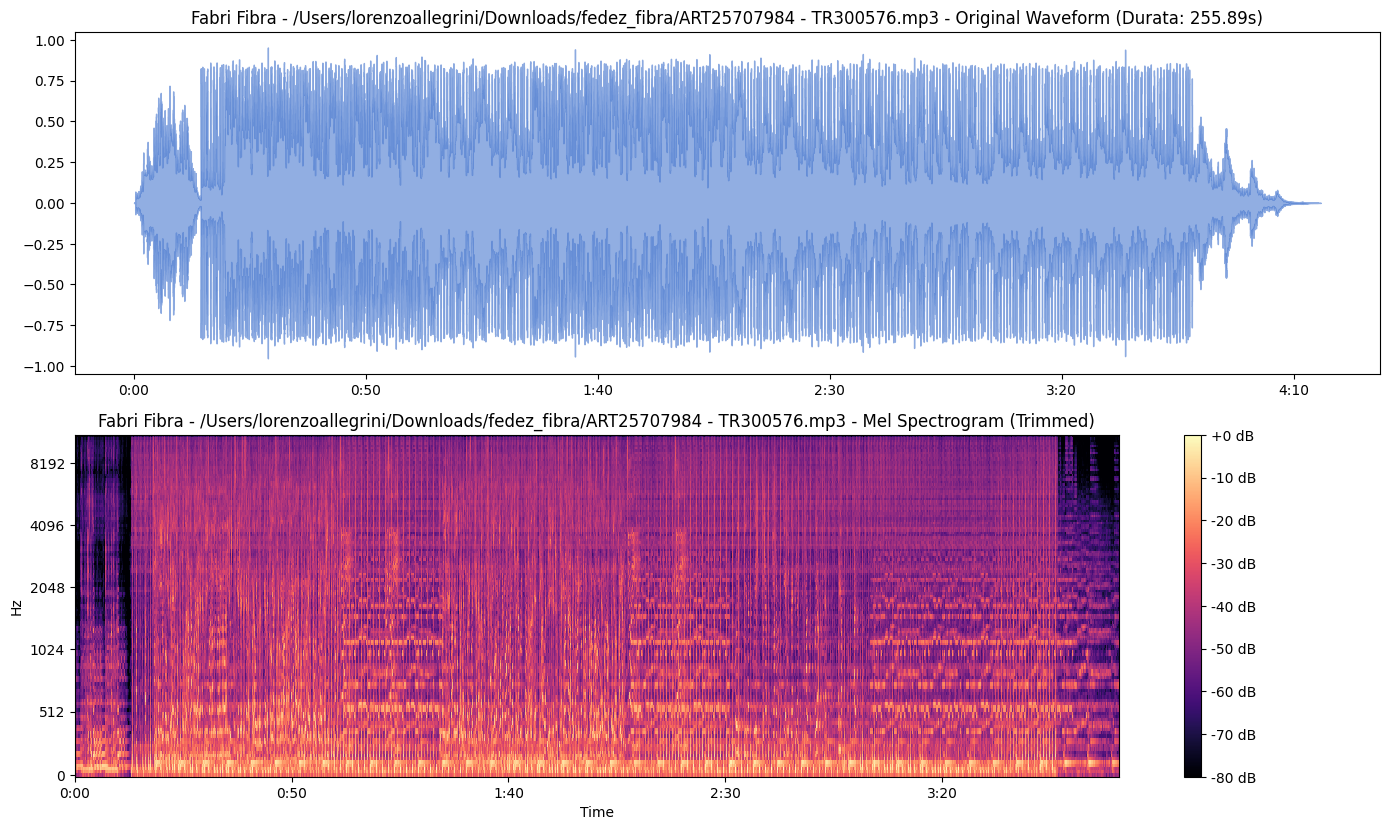

In [472]:
def visualize_audio(file_path, title="Audio Visualization"):
    y, sr = librosa.load(file_path, sr=22050)
    
    y_trimmed, index = librosa.effects.trim(y, top_db=20)
    
    plt.figure(figsize=(14, 12)) 
    
    plt.subplot(3, 1, 1)
    librosa.display.waveshow(y, sr=sr, alpha=0.6)
    plt.title(f"{title} - Original Waveform (Durata: {librosa.get_duration(y=y, sr=sr):.2f}s)")
    plt.xlabel("") # Rimuovo label x per pulizia
    
    plt.subplot(3, 1, 2)
    S = librosa.feature.melspectrogram(y=y_trimmed, sr=sr, n_mels=128)
    S_dB = librosa.power_to_db(S, ref=np.max)
    
    img = librosa.display.specshow(S_dB, sr=sr, x_axis='time', y_axis='mel')
    plt.colorbar(img, format='%+2.0f dB')
    plt.title(f"{title} - Mel Spectrogram (Trimmed)")
    
    plt.tight_layout()
    plt.show()

for sample in fedez_files[:1]:
    visualize_audio(os.path.join(MP3_FOLDER, sample), title=f"Fedez - {sample}")

for sample in fibra_files[:1]:
    visualize_audio(os.path.join(MP3_FOLDER, sample), title=f"Fabri Fibra - {sample}")

## Feature extraction

In [473]:
target_length = 500
resampler = TimeSeriesResampler(sz=target_length)

In [474]:
mert_extractor = FeatureExtractor(model_ids=["m-a-p/MERT-v1-95M"], sampling_rates=[24000])
all_features = []

for file_path in tqdm(all_files):
    features = mert_extractor.extract_features(
        file_path=file_path,
        cache_dir="../extracted_features"  
    )
    all_features.append(features)

mert_embeddings = resampler.fit_transform(all_features)  # shape: (n_songs, 500, 768)


100%|██████████| 30/30 [00:01<00:00, 19.47it/s]


In [475]:
wav2vec2_extractor = FeatureExtractor(model_ids=["facebook/wav2vec2-base"], sampling_rates=[16000])
all_features = []

for file_path in tqdm(all_files):
    features = wav2vec2_extractor.extract_features(
        file_path=file_path,
        cache_dir="../extracted_features"  
    )
    all_features.append(features)
    
wav2vec2_embeddings = resampler.fit_transform(all_features)  # shape: (n_songs, 500, 768)

100%|██████████| 30/30 [00:01<00:00, 17.70it/s]


In [476]:
mert_wav2vec2_extractor = FeatureExtractor()
all_features = []

for file_path in tqdm(all_files):
    features = mert_wav2vec2_extractor.extract_features(
        file_path=file_path,
        cache_dir="../extracted_features"  
    )
    all_features.append(features)

mert_wav2vec2_embeddings = resampler.fit_transform(all_features)  # shape: (n_songs, 500, 768)


100%|██████████| 30/30 [00:02<00:00, 10.40it/s]


## Clustering by global pooling on embeddings with MERT

In [477]:
global_mert_embedding = mert_embeddings.mean(axis=1)
normalizer = Normalizer()
mert_embeddings_normalized = normalizer.fit_transform(global_mert_embedding)

pca = PCA(n_components=0.9) # keep 90% of the variance
mert_embeddings_pca = pca.fit_transform(mert_embeddings_normalized)

print(f"Reduced to {mert_embeddings_pca.shape[1]} dimensions.")

Reduced to 20 dimensions.


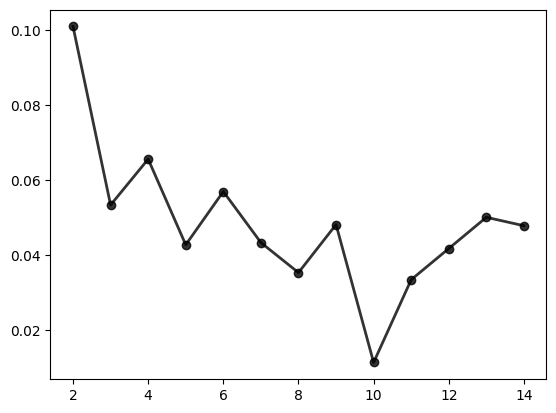

In [478]:
from sklearn.metrics import silhouette_score

scores = []
k_values = range(2,15)
for i in k_values:
    kmeans = KMeans(n_clusters=i, random_state=42, n_init=10)
    predicted_clusters = kmeans.fit_predict(mert_embeddings_pca)
    scores.append(silhouette_score(mert_embeddings_pca, predicted_clusters))

fig, axes = plt.subplots()
plt.plot(k_values, scores, marker='o', color='black', linestyle='-', linewidth=2, alpha=0.8)
plt.show()

use the number of clusters based on the elbow

In [479]:
kmeans = KMeans(n_clusters=6, random_state=42, n_init=10)
predicted_clusters = kmeans.fit_predict(mert_embeddings_pca)

In [480]:
def plot_clusters_scatter(reducer, embeddings, predicted_clusters, figsize=(10,6)):

    X_umap = reducer.fit_transform(embeddings)

    unique_clusters = np.unique(predicted_clusters)

    cluster_samples = []
    samples_per_cluster = 15

    for c in unique_clusters:
        idx_cluster = np.where(predicted_clusters == c)[0]  
        X_c = embeddings[idx_cluster]

        centroid = X_c.mean(axis=0)
        dist_to_centroid = np.linalg.norm(X_c - centroid, axis=1)

        closest_idx_local = np.argsort(dist_to_centroid)[:samples_per_cluster]
        closest_idx_global = idx_cluster[closest_idx_local]

        cluster_samples.append(closest_idx_global)


    plt.figure(figsize=figsize)

    sns.scatterplot(
        x=X_umap[:, 0], 
        y=X_umap[:, 1], 
        hue=predicted_clusters, 
        palette='colorblind',
        s=100,
        legend='full',
        alpha=0.6
    )

    plt.title('UMAP Projection (Fedez vs Fibra)')
    plt.xlabel("UMAP 1")
    plt.ylabel("UMAP 2")
    plt.legend()
    plt.show()

    return cluster_samples


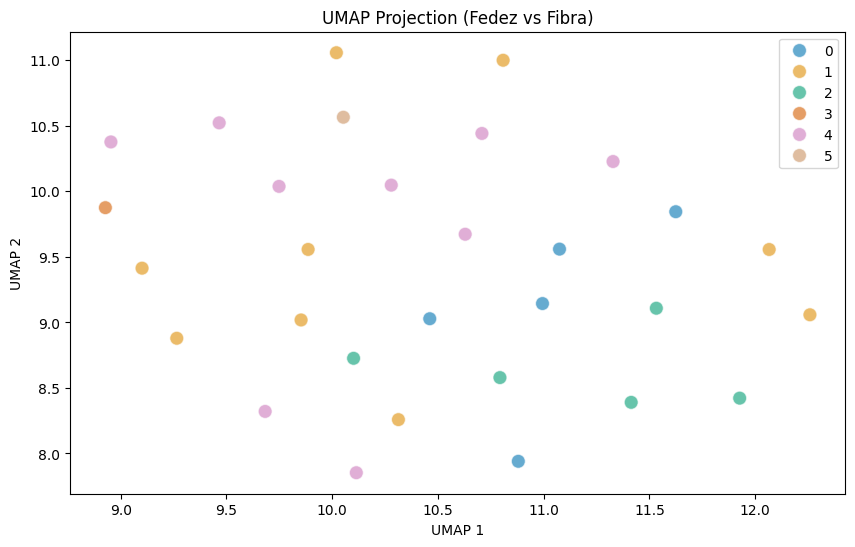

In [481]:
reducer = umap.UMAP(
    n_neighbors=30,  
    min_dist=0.1, 
    n_components=2, 
    random_state=42
)
cluster_samples = plot_clusters_scatter(reducer, mert_embeddings_pca, predicted_clusters)

### Cluster Interpretability

In [482]:
from transformers import ClapModel, ClapProcessor
model = ClapModel.from_pretrained("laion/clap-htsat-unfused")
processor = ClapProcessor.from_pretrained("laion/clap-htsat-unfused")

rap_styles = [
    "Old School Boom Bap",       
    "Hardcore Aggressive Rap",   
    "Conscious Storytelling",    
    "Double Time Rap",          
    
    "Italian Pop Rap",         
    "Melodic Autotuned Rap",     
    "Electronic Club Rap",       

    "Modern Trap",              
    "Dark Emo Rap",             
    "Chill Lo-Fi Hip Hop",      
]

structure_labels = [
    "Very repetitive sections",
    "Clear verse-chorus structure",
    "Evolving sections with noticeable changes",
    "Chaotic or fragmented structure",
    "Gradual build-up increasing intensity",
    "Minimal variation, repetitive loops",
    "Choruses differ significantly from verses"
]

density_labels = [
    "Very dense, many overlapping layers",
    "Moderately dense, balanced elements",
    "Sparse, few instruments, lots of space",
    "Alternating sparse and dense sections",
    "Cluttered with overlapping melodic/percussive elements",
    "Very light instrumentation, focus on silence/space"
]

voice_balance_labels = [
    "Vocals clearly dominant",
    "Instrumental dominant with vocals blended",
    "Vocals and instrumental equally balanced",
    "Vocals dominate only in choruses",
    "Vocals blend in the background",
    "Vocals prominent in some passages, minimal in others"
]

tempo_perception_labels = [
    "Fast and urgent",
    "Steady, moderate pacing",
    "Slow or stretched",
    "Variable tempo within sections",
    "Mostly slow with occasional bursts",
    "Irregular or syncopated, hard to perceive steady beat"
]

def clap_classify(labels, y, sr):
    inputs = processor(
        text=labels,
        audio=y,
        return_tensors="pt",
        padding=True,
        sampling_rate=sr
    )
    outputs = model(**inputs)
    probs = outputs.logits_per_audio.softmax(dim=1)
    return probs[0]

def apply_clap_labelling(cluster_samples, sr=48000):
    cluster_prompt_means = []

    for cluster_idx, cluster in enumerate(cluster_samples):
        cluster_dict = {}
        
        for name, labels in [
            ("Style", rap_styles),
            ("Structure", structure_labels),
            ("Density", density_labels),
            ("VoiceBalance", voice_balance_labels),
            ("TempoPerception", tempo_perception_labels)
        ]:
            probs_list = []

            
            for song_idx in cluster:
                y, sr = librosa.load(all_files[song_idx], sr=48000)
                probs = clap_classify(labels, y, sr) 
                probs_list.append(probs.detach().cpu().numpy())  

            mean_probs = np.mean(np.stack(probs_list), axis=0)  
            cluster_dict[name] = mean_probs

        cluster_prompt_means.append(cluster_dict)

    return cluster_prompt_means


def plot_clap_labels(cluster_prompt_means, label_type, prompt_list, top_n=10, cols=2, figsize_unit=(8, 5)):
    """
    Plots semantic identity for clusters with configurable parameters.
    
    Args:
        cluster_prompt_means (list): List of dicts containing "Style" vectors.
        prompt_list (list): List of strings representing prompts.
        top_n (int): Number of top styles to show per cluster.
        cols (int): Number of columns in the subplot grid.
        figsize_unit (tuple): (width, height) per individual cluster plot.
    """
    all_means = np.array([d[label_type] for d in cluster_prompt_means])
    global_style_mean = np.mean(all_means, axis=0)

    n_clusters = len(cluster_prompt_means)
    rows = (n_clusters + cols - 1) // cols
    
    fig, axes = plt.subplots(rows, cols, figsize=(figsize_unit[0] * cols, figsize_unit[1] * rows))
    axes = np.atleast_1d(axes).flatten()
    cmap = plt.get_cmap('tab10') 

    for i in range(n_clusters):
        ax = axes[i]
        
        relevance = cluster_prompt_means[i][label_type] - global_style_mean
        top_indices = np.argsort(relevance)[-top_n:]
        top_labels = [prompt_list[idx] for idx in top_indices]
        top_values = relevance[top_indices]
        
        color = cmap(i % 10)
        ax.barh(top_labels, top_values, color=color, alpha=0.8)
        
        ax.set_title(f"Semantic Identity: Cluster {i}", fontsize=14, fontweight='bold')
        ax.set_xlabel("Relative Relevance (Deviation from Mean)")
        ax.axvline(0, color='black', linewidth=0.8)
        ax.grid(axis='x', linestyle='--', alpha=0.3)

    # Clean up empty subplots
    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])

    plt.tight_layout()
    plt.show()

In [483]:
cluster_prompt_means = apply_clap_labelling(cluster_samples)

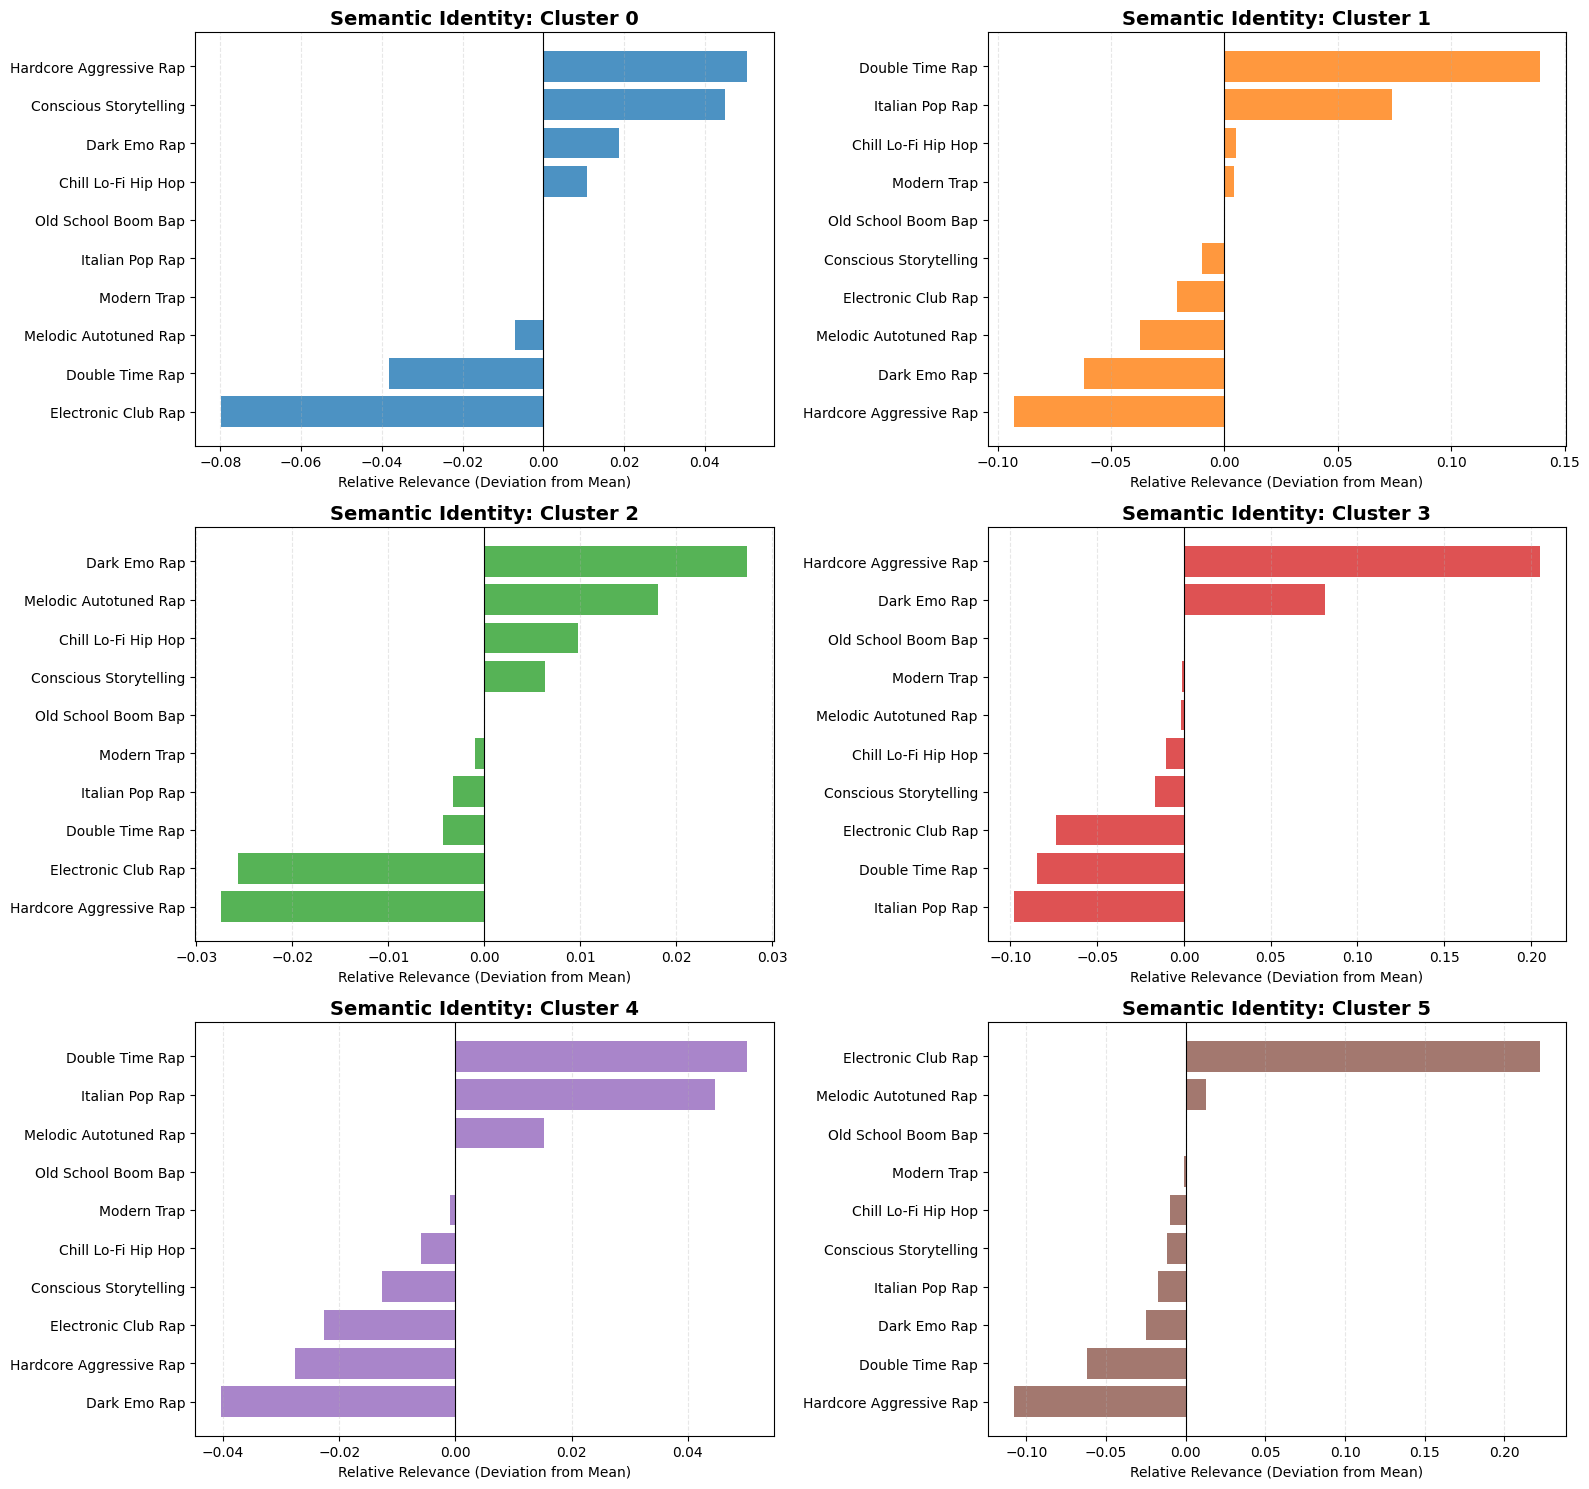

In [484]:
plot_clap_labels(cluster_prompt_means, "Style", rap_styles)

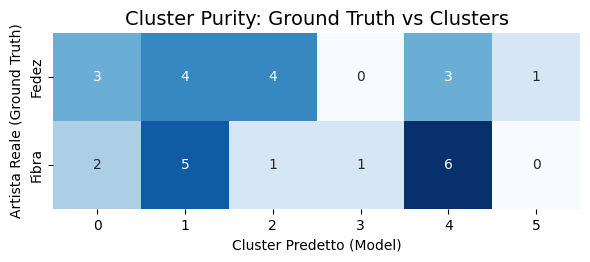

Cluster Predetto (Model),0,1,2,3,4,5
Artista Reale (Ground Truth),,,,,,
Fedez,3,4,4,0,3,1
Fibra,2,5,1,1,6,0


In [485]:
true_labels = ["Fedez" if f in fedez_files else "Fibra" for f in all_files]
plot_cluster_purity(true_labels, predicted_clusters)

## Clustering by global pooling on embeddings with Wav2Vec2-base

In [486]:
global_wav2vec2_embedding = wav2vec2_embeddings.mean(axis=1)
wav2vec2_embeddings_normalized = normalizer.fit_transform(global_wav2vec2_embedding)
wav2vec2_embeddings_pca = pca.fit_transform(wav2vec2_embeddings_normalized)

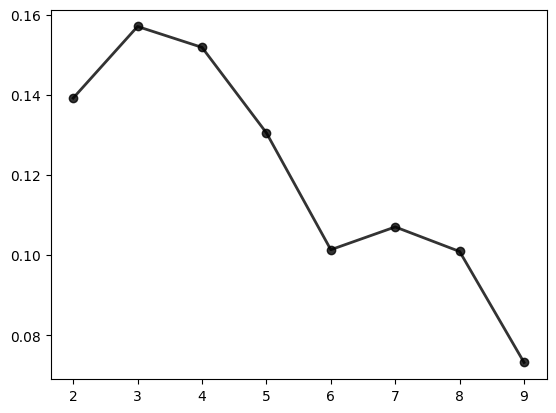

In [487]:
from sklearn.metrics import silhouette_score, adjusted_rand_score, classification_report, confusion_matrix

scores = []
k_values = range(2,10)
for i in k_values:
    kmeans = KMeans(n_clusters=i, random_state=42, n_init=10)
    predicted_clusters = kmeans.fit_predict(wav2vec2_embeddings_pca)
    scores.append(silhouette_score(wav2vec2_embeddings_pca, predicted_clusters))


fig, axes = plt.subplots()
plt.plot(k_values, scores, marker='o', color='black', linestyle='-', linewidth=2, alpha=0.8)
plt.show()

In [488]:
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
predicted_clusters = kmeans.fit_predict(wav2vec2_embeddings_pca)

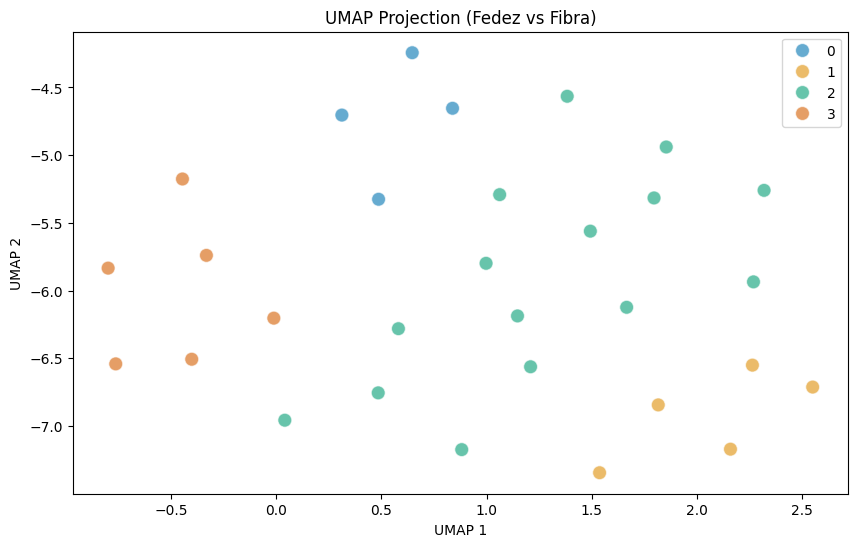

In [489]:
reducer = umap.UMAP(
    n_neighbors=30,  
    min_dist=0.1, 
    n_components=2, 
    random_state=42
)
cluster_samples = plot_clusters_scatter(reducer, wav2vec2_embeddings_pca, predicted_clusters)

### Cluster Interpretability

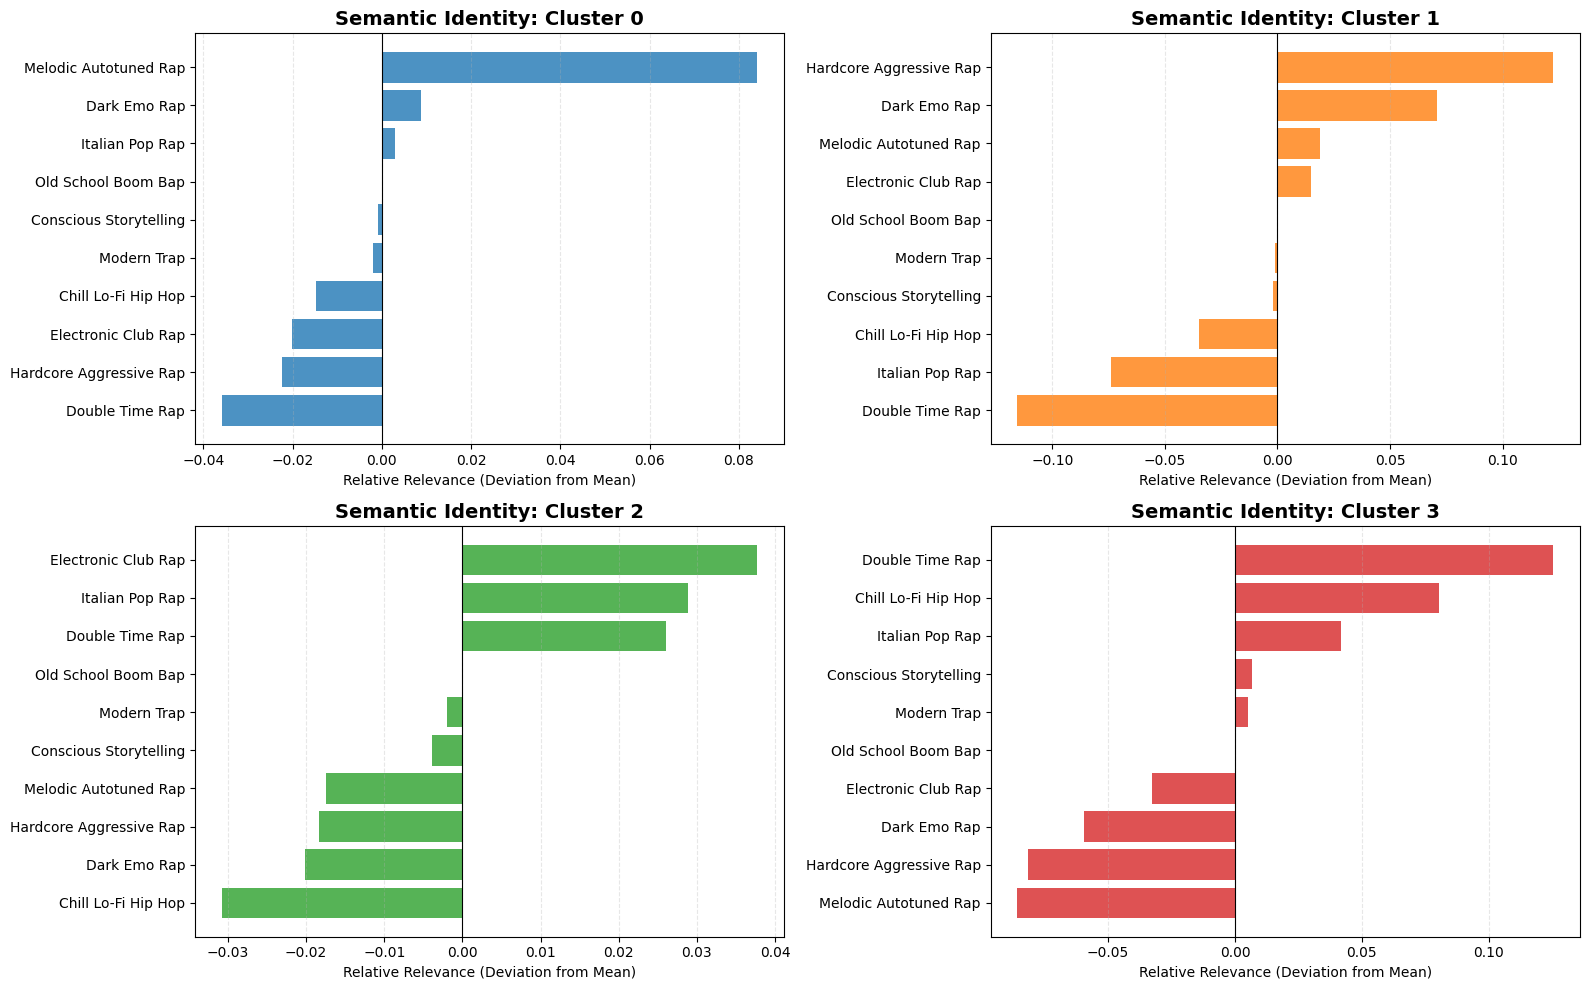

In [490]:
cluster_prompt_means = apply_clap_labelling(cluster_samples)
plot_clap_labels(cluster_prompt_means, "Style", rap_styles)

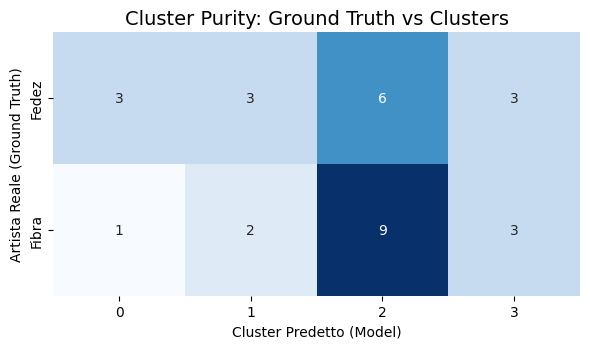

Cluster Predetto (Model),0,1,2,3
Artista Reale (Ground Truth),,,,
Fedez,3,3,6,3
Fibra,1,2,9,3


In [491]:
plot_cluster_purity(true_labels, predicted_clusters)

## Clustering by mean pooling of embeddings with both MERT and Wav2Vec2

In [492]:
global_mert_wav2vec2_embedding = mert_wav2vec2_embeddings.mean(axis=1)
mert_wav2vec2_embeddings_normalized = normalizer.fit_transform(global_mert_wav2vec2_embedding)
mert_wav2vec2_embeddings_pca = pca.fit_transform(mert_wav2vec2_embeddings_normalized)

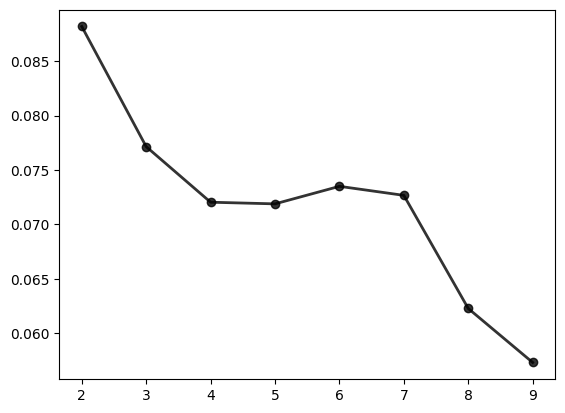

In [493]:
from sklearn.metrics import silhouette_score, adjusted_rand_score, classification_report, confusion_matrix

scores = []
k_values = range(2,10)
for i in k_values:
    kmeans = KMeans(n_clusters=i, random_state=42, n_init=10)
    predicted_clusters = kmeans.fit_predict(mert_wav2vec2_embeddings_pca)
    scores.append(silhouette_score(mert_wav2vec2_embeddings_pca, predicted_clusters))


fig, axes = plt.subplots()
plt.plot(k_values, scores, marker='o', color='black', linestyle='-', linewidth=2, alpha=0.8)
plt.show()

In [494]:
kmeans = KMeans(n_clusters=6, random_state=42, n_init=10)
predicted_clusters = kmeans.fit_predict(mert_wav2vec2_embeddings_pca)

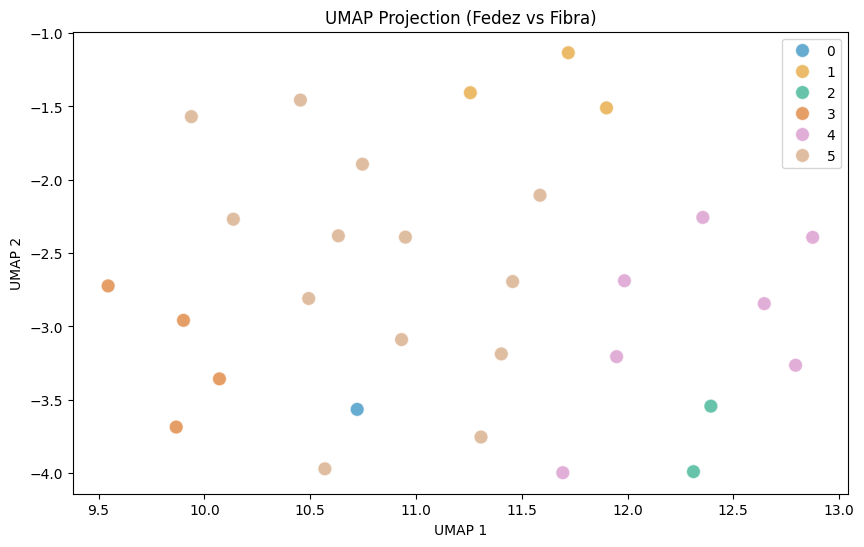

In [495]:
reducer = umap.UMAP(
    n_neighbors=30,  
    min_dist=0.1, 
    n_components=2, 
    random_state=42
)
cluster_samples = plot_clusters_scatter(reducer, mert_wav2vec2_embeddings_pca, predicted_clusters)

### Cluster Interpretability

In [496]:
cluster_prompt_means = apply_clap_labelling(cluster_samples)

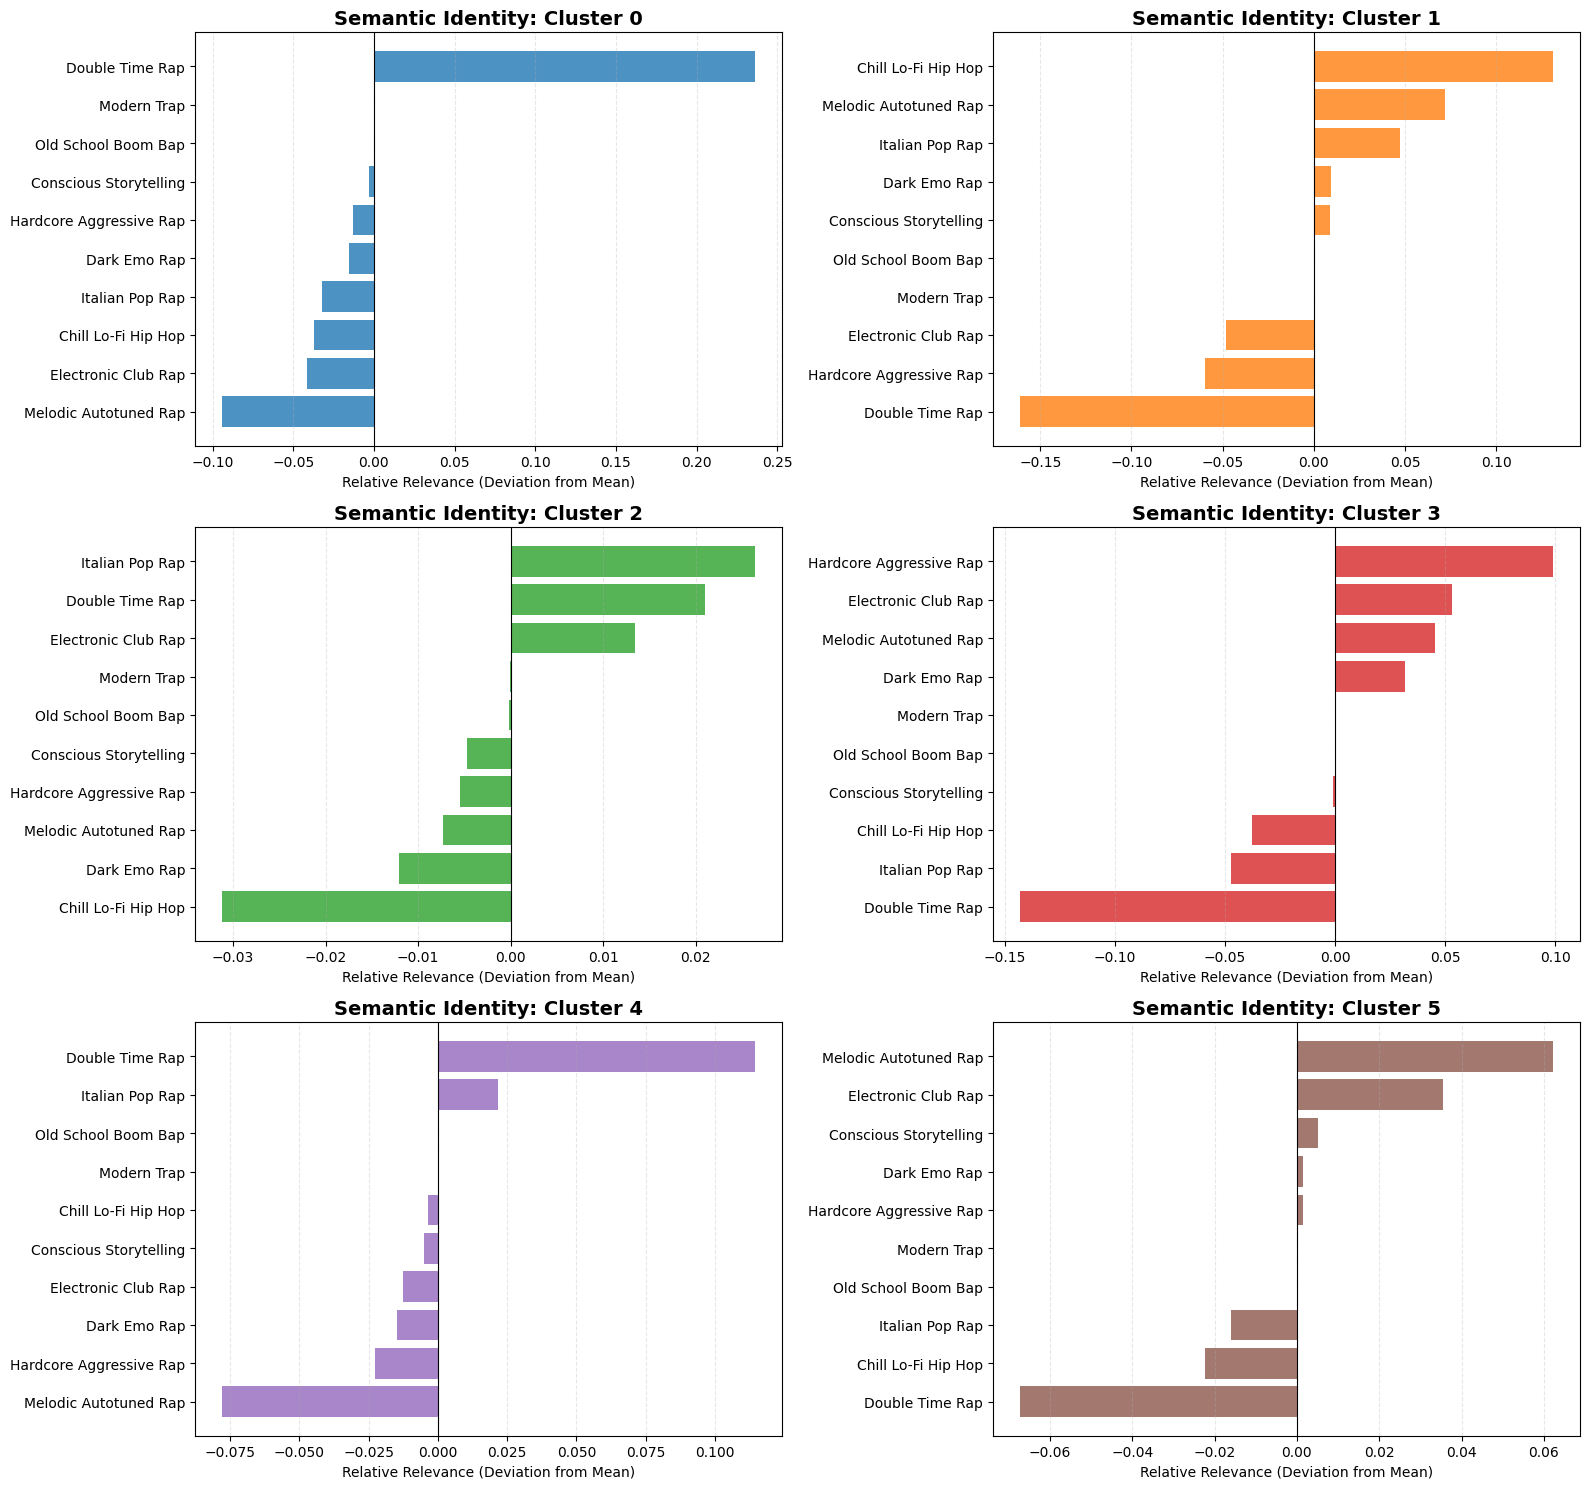

In [497]:
plot_clap_labels(cluster_prompt_means, "Style", rap_styles)

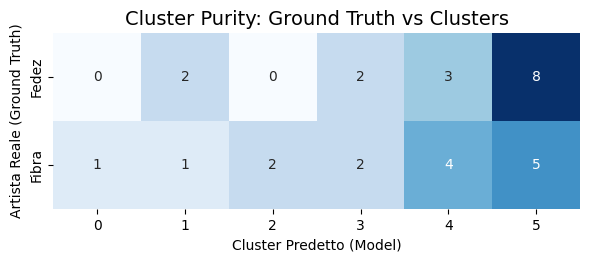

Cluster Predetto (Model),0,1,2,3,4,5
Artista Reale (Ground Truth),,,,,,
Fedez,0,2,0,2,3,8
Fibra,1,1,2,2,4,5


In [498]:
plot_cluster_purity(true_labels, predicted_clusters)

## Clustering by DTW on MERT embeddings

### PCA

In [499]:
n_songs, n_time, n_feat = mert_embeddings.shape
mert_embeddings_flat = mert_embeddings.reshape(n_songs * n_time, n_feat)

pca = PCA(n_components=5)
mask = ~np.isnan(mert_embeddings_flat).any(axis=1)

mert_embeddings_valid = mert_embeddings_flat[mask]
mert_embeddings_pca_valid = pca.fit_transform(mert_embeddings_valid)

mert_embeddings_pca_full = np.full((mert_embeddings_flat.shape[0], pca.n_components), np.nan)
mert_embeddings_pca_full[mask] = mert_embeddings_pca_valid

mert_embeddings_pca = mert_embeddings_pca_full.reshape(n_songs, n_time, -1)
scaler = TimeSeriesScalerMeanVariance()
mert_embeddings_scaled = scaler.fit_transform(mert_embeddings_pca)
mert_embeddings_scaled = np.nan_to_num(mert_embeddings_scaled) 

In [500]:
def get_prototypes_dtw(X, kmeans_model, predicted_clusters, samples_per_cluster=15):
    cluster_samples = []
    n_clusters = kmeans_model.n_clusters
    distances_matrix = kmeans_model.transform(X)

    for c in range(n_clusters):
        idx_in_cluster = np.where(predicted_clusters == c)[0]
        
        if len(idx_in_cluster) == 0:
            cluster_samples.append([])
            continue

        dists_to_center = distances_matrix[idx_in_cluster, c]
        closest_idx_local = np.argsort(dists_to_center)[:samples_per_cluster]
        
        closest_idx_global = idx_in_cluster[closest_idx_local]
        
        cluster_samples.append(closest_idx_global)
        
    return cluster_samples

In [501]:
import matplotlib.pyplot as plt
from tslearn.clustering import TimeSeriesKMeans
from tqdm import tqdm

def plot_ts_elbow_method(X, k_range=(2, 10), metric="dtw", max_iter=10, n_init=3, figsize=(10, 6), title=None):
    
    scores = []

    if isinstance(k_range, tuple):
        k_values = range(k_range[0], k_range[1])
    else:
        k_values = k_range

    for k in tqdm(k_values):
        kmeans = TimeSeriesKMeans(
            n_clusters=k,
            metric=metric,
            max_iter=max_iter,
            n_init=n_init,
            verbose=False,
            random_state=42,
            n_jobs=-1  
        )
        
        kmeans.fit(X)
        scores.append(kmeans.inertia_)

    plt.figure(figsize=figsize)
    plt.plot(k_values, scores, marker='o', color='black', linestyle='-', linewidth=2, alpha=0.8)

    if title is None:
        title = f"Elbow Method: Inertia vs K (Metric: {metric})"
    
    plt.title(title)
    plt.xlabel("Number of Clusters (k)")
    plt.ylabel(f"Inertia ({metric} distance)")
    plt.grid(True, alpha=0.3)
    plt.xticks(k_values)  # Forza a mostrare tutti i numeri interi sull'asse X
    
    plt.show()
    
    return scores

In [ ]:
scores = plot_ts_elbow_method(
    mert_embeddings_scaled, 
    k_range=(2, 10), 
    metric="dtw",
    max_iter=20
)

 50%|█████     | 4/8 [00:37<00:38,  9.71s/it]

In [ ]:
kmeans = TimeSeriesKMeans(
    n_clusters=5,
    metric="dtw",
    max_iter=10,
    n_init=3,
    verbose=False,
    random_state=42
)
predicted_clusters = kmeans.fit_predict(mert_embeddings_scaled)

In [ ]:
plot_timeseries_clusters(mert_embeddings_scaled, predicted_clusters, centroids=kmeans.cluster_centers_, feature_idx=0, title="Time Series Clustering")

In [ ]:
cluster_samples = get_prototypes_dtw(
    X=mert_embeddings_scaled, 
    kmeans_model=kmeans, 
    predicted_clusters=predicted_clusters, 
    samples_per_cluster=15
)
cluster_prompt_means = apply_clap_labelling(cluster_samples)
plot_clap_labels(cluster_prompt_means, "Style", rap_styles)

### UMAP

In [ ]:
n_songs, n_time, n_feat = mert_embeddings.shape
mert_embeddings_flat = mert_embeddings.reshape(n_songs * n_time, n_feat)

mask = ~np.isnan(mert_embeddings_flat).any(axis=1)

mert_embeddings_valid = mert_embeddings_flat[mask]

pre_scaler = StandardScaler()
mert_embeddings_valid_scaled = pre_scaler.fit_transform(mert_embeddings_valid)

reducer = umap.UMAP(
    n_components=5, 
    n_neighbors=30,    
    min_dist=0.1,      
    metric='cosine',   
    random_state=42,
    n_jobs=-1          
)

mert_embeddings_umap_valid = reducer.fit_transform(mert_embeddings_valid_scaled)
mert_embeddings_umap_full = np.full((mert_embeddings_flat.shape[0], 5), np.nan)
mert_embeddings_umap_full[mask] = mert_embeddings_umap_valid


mert_embeddings_umap = mert_embeddings_umap_full.reshape(n_songs, n_time, -1)

scaler = TimeSeriesScalerMeanVariance()
mert_embeddings_scaled = scaler.fit_transform(mert_embeddings_umap)
mert_embeddings_scaled = np.nan_to_num(mert_embeddings_scaled)

100%|██████████| 8/8 [1:14:23<00:00, 557.91s/it]


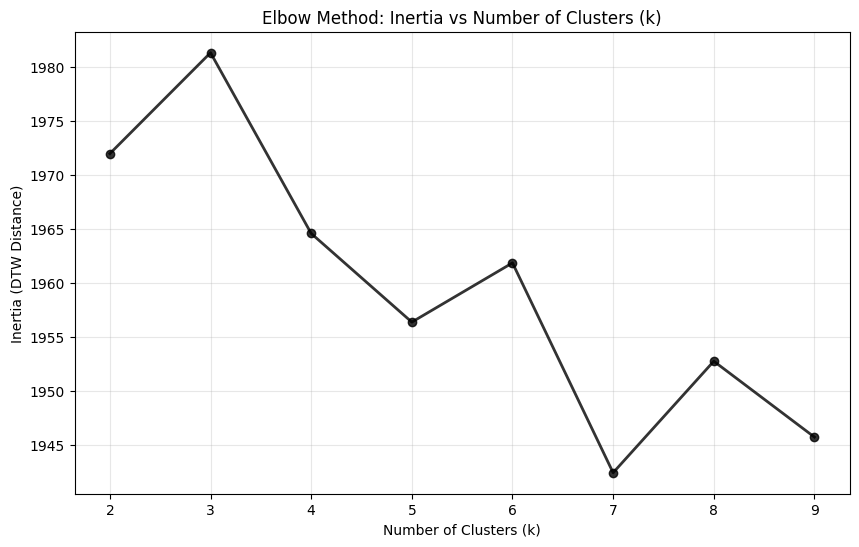

In [ ]:
scores = plot_ts_elbow_method(
    mert_embeddings_scaled, 
    k_range=(2, 10), 
    metric="dtw",
    max_iter=20
)

In [ ]:
kmeans = TimeSeriesKMeans(
    n_clusters=5,
    metric="dtw",
    max_iter=10,
    n_init=3,
    verbose=False,
    random_state=42
)
predicted_clusters = kmeans.fit_predict(mert_embeddings_scaled)

In [ ]:
plot_timeseries_clusters(mert_embeddings_scaled, predicted_clusters, centroids=kmeans.cluster_centers_, feature_idx=0, title="Time Series Clustering")

In [ ]:
cluster_samples = get_prototypes_dtw(
    X=mert_embeddings_scaled, 
    kmeans_model=kmeans, 
    predicted_clusters=predicted_clusters, 
    samples_per_cluster=15
)
cluster_prompt_means = apply_clap_labelling(cluster_samples)
plot_clap_labels(cluster_prompt_means, "Style", rap_styles)

### PCA

In [ ]:
n_songs, n_time, n_feat = wav2vec2_embeddings.shape
wav2vec2_embeddings_flat = wav2vec2_embeddings.reshape(n_songs * n_time, n_feat)

pca = PCA(n_components=5)
mask = ~np.isnan(wav2vec2_embeddings_flat).any(axis=1)

wav2vec2_embeddings_valid = wav2vec2_embeddings_flat[mask]
wav2vec2_embeddings_pca_valid = pca.fit_transform(wav2vec2_embeddings_valid)

wav2vec2_embeddings_pca_full = np.full((wav2vec2_embeddings_flat.shape[0], pca.n_components), np.nan)
wav2vec2_embeddings_pca_full[mask] = wav2vec2_embeddings_pca_valid

wav2vec2_embeddings_pca = wav2vec2_embeddings_pca_full.reshape(n_songs, n_time, -1)

scaler = TimeSeriesScalerMeanVariance()
wav2vec2_embeddings_scaled = scaler.fit_transform(wav2vec2_embeddings_pca)

wav2vec2_embeddings_scaled = np.nan_to_num(wav2vec2_embeddings_scaled)
wav2vec2_embeddings_scaled.shape

In [ ]:
scores = plot_ts_elbow_method(
    wav2vec2_embeddings_scaled, 
    k_range=(2, 10), 
    metric="dtw",
    max_iter=20
)

In [ ]:
kmeans = TimeSeriesKMeans(
    n_clusters=5,
    metric="dtw",
    max_iter=10,
    n_init=3,
    verbose=False,
    random_state=42
)
predicted_clusters = kmeans.fit_predict(wav2vec2_embeddings_scaled)

In [ ]:
plot_timeseries_clusters(wav2vec2_embeddings_scaled, predicted_clusters, centroids=kmeans.cluster_centers_, feature_idx=0, title="Time Series Clustering")

In [ ]:
cluster_samples = get_prototypes_dtw(
    X=wav2vec2_embeddings_scaled, 
    kmeans_model=kmeans, 
    predicted_clusters=predicted_clusters, 
    samples_per_cluster=15
)
cluster_prompt_means = apply_clap_labelling(cluster_samples)
plot_clap_labels(cluster_prompt_means, "Style", rap_styles)

### UMAP

In [ ]:
n_songs, n_time, n_feat = wav2vec2_embeddings.shape
wav2vec2_embeddings_flat = wav2vec2_embeddings.reshape(n_songs * n_time, n_feat)

mask = ~np.isnan(wav2vec2_embeddings_flat).any(axis=1)

wav2vec2_embeddings_valid = wav2vec2_embeddings_flat[mask]

pre_scaler = StandardScaler()
wav2vec2_embeddings_valid_scaled = pre_scaler.fit_transform(wav2vec2_embeddings_valid)

reducer = umap.UMAP(
    n_components=5, 
    n_neighbors=30,    
    min_dist=0.1,      
    metric='cosine',   
    random_state=42,
    n_jobs=-1          
)

wav2vec2_embeddings_umap_valid = reducer.fit_transform(wav2vec2_embeddings_valid_scaled)

wav2vec2_embeddings_umap_full = np.full((wav2vec2_embeddings_flat.shape[0], 5), np.nan)
wav2vec2_embeddings_umap_full[mask] = wav2vec2_embeddings_umap_valid

wav2vec2_embeddings_umap = wav2vec2_embeddings_umap_full.reshape(n_songs, n_time, -1)

scaler = TimeSeriesScalerMeanVariance()
wav2vec2_embeddings_scaled = scaler.fit_transform(wav2vec2_embeddings_umap)

wav2vec2_embeddings_scaled = np.nan_to_num(wav2vec2_embeddings_scaled)
wav2vec2_embeddings_scaled.shape

100%|██████████| 8/8 [1:14:23<00:00, 557.91s/it]


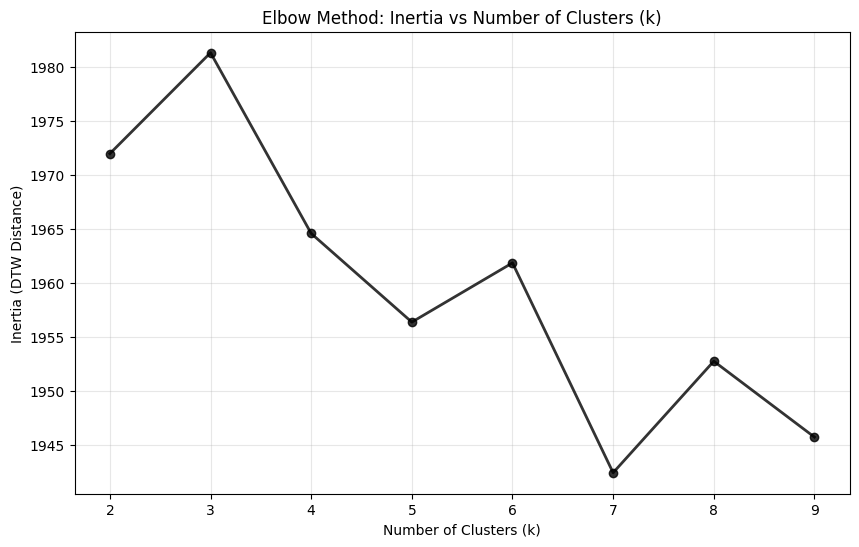

In [ ]:
scores = plot_ts_elbow_method(
    wav2vec2_embeddings_scaled, 
    k_range=(2, 10), 
    metric="dtw",
    max_iter=20
)

In [ ]:
kmeans = TimeSeriesKMeans(
    n_clusters=5,
    metric="dtw",
    max_iter=10,
    n_init=3,
    verbose=False,
    random_state=42
)
predicted_clusters = kmeans.fit_predict(wav2vec2_embeddings_scaled)

In [ ]:
plot_timeseries_clusters(wav2vec2_embeddings_scaled, predicted_clusters, centroids=kmeans.cluster_centers_, feature_idx=0, title="Time Series Clustering")

In [ ]:
cluster_samples = get_prototypes_dtw(
    X=wav2vec2_embeddings_scaled, 
    kmeans_model=kmeans, 
    predicted_clusters=predicted_clusters, 
    samples_per_cluster=15
)
cluster_prompt_means = apply_clap_labelling(cluster_samples)
plot_clap_labels(cluster_prompt_means, "Style", rap_styles)

## NCD based clustering

Calcolo della matrice delle distanze CDM (potrebbe richiedere tempo)...
Shape originale: (454, 500, 5)
Shape input per pdist: (454, 2500)
Matrice calcolata. Shape: (454, 454)
Test clustering per vari k...


100%|██████████| 4/4 [00:00<00:00, 91.10it/s]

Miglior numero di cluster (k): 2
Miglior Silhouette Score: 0.0020


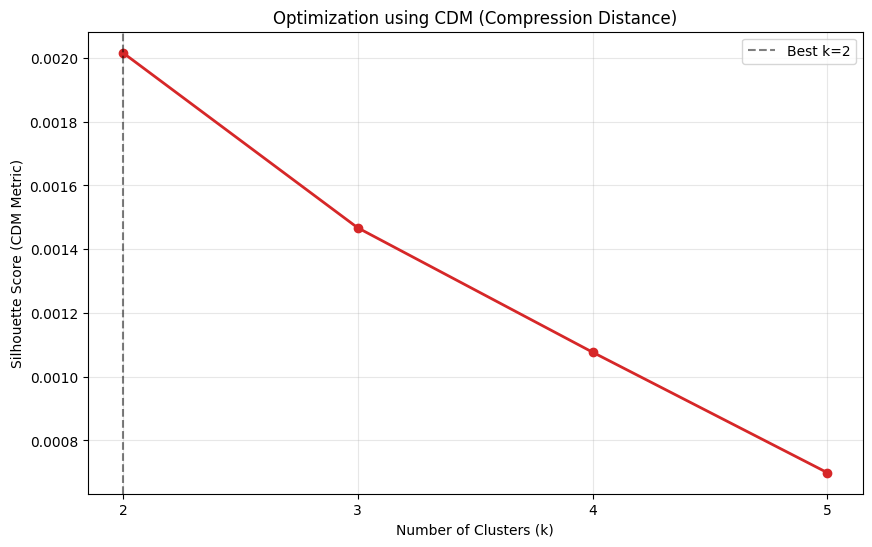

In [ ]:
import zlib
import numpy as np
import matplotlib.pyplot as plt
from scipy.spatial.distance import pdist, squareform
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import silhouette_score
from tqdm import tqdm

# --- 1. Definizione della metrica CDM (Compression-based Dissimilarity Measure) ---
def cdm_dist(x, y):
    # Convertiamo i dati in stringa di byte per zlib
    # Usiamo f-string con precisione per coerenza
    x_str = (' '.join([f"{v:.5f}" for v in x.ravel()])).encode('utf-8')
    y_str = (' '.join([f"{v:.5f}" for v in y.ravel()])).encode('utf-8')
    
    # Calcolo compressioni
    len_x = len(zlib.compress(x_str))
    len_y = len(zlib.compress(y_str))
    len_xy = len(zlib.compress(x_str + y_str))
    
    # Formula CDM
    return len_xy / (len_x + len_y)

# --- 2. Pre-calcolo della Matrice delle Distanze ---
print("Calcolo della matrice delle distanze CDM (potrebbe richiedere tempo)...")

# FIX CRITICO: pdist richiede una matrice 2D (n_samples, n_features).
# X_scaled è 3D (n_songs, n_time, n_features).
# Dobbiamo appiattirlo in 2D.
n_samples = X_scaled.shape[0]
X_flattened = X_scaled.reshape(n_samples, -1)

print(f"Shape originale: {X_scaled.shape}")
print(f"Shape input per pdist: {X_flattened.shape}")

# pdist calcola le distanze a coppie usando la tua funzione custom
distance_vector = pdist(X_flattened, metric=cdm_dist)
distance_matrix = squareform(distance_vector)

print("Matrice calcolata. Shape:", distance_matrix.shape)

# --- 3. Ricerca del Clustering Ottimale ---
k_values = range(2, 6) # Range ridotto per test rapido, aumentalo a 10 se vuoi
scores = []

print("Test clustering per vari k...")
for k in tqdm(k_values):
    # 'metric'='precomputed' dice al modello di usare la matrice delle distanze
    model = AgglomerativeClustering(
        n_clusters=k, 
        metric='precomputed', 
        linkage='average' 
    )
    
    labels = model.fit_predict(distance_matrix)
    
    # Calcolo Silhouette Score con la metrica precomputata
    if len(set(labels)) > 1:
        score = silhouette_score(distance_matrix, labels, metric='precomputed')
    else:
        score = -1
        
    scores.append(score)

# --- 4. Plotting dei Risultati ---
plt.figure(figsize=(10, 6))
plt.plot(k_values, scores, marker='o', color='#d62728', linewidth=2)
plt.title("Optimization using CDM (Compression Distance)")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Silhouette Score (CDM Metric)")
plt.grid(True, alpha=0.3)
plt.xticks(k_values)

# Evidenzia il miglior K
if len(scores) > 0:
    best_idx = np.argmax(scores)
    best_k = k_values[best_idx]
    best_score = scores[best_idx]
    plt.axvline(best_k, color='black', linestyle='--', alpha=0.5, label=f'Best k={best_k}')
    
    print(f"Miglior numero di cluster (k): {best_k}")
    print(f"Miglior Silhouette Score: {best_score:.4f}")

plt.legend()
plt.show()


## Anomaly Detection

In [ ]:
model_id = "hugggof/vampnet-base-best" # Checkpoint ufficiale su HuggingFace
chunk_sec = 10       # VampNet lavora meglio su chunk più corti (10s è standard)
stride_sec = 5       # Sovrapposizione
mask_window_sec = 0.5 # QUANTO audio nascondiamo ogni volta per testare la sorpresa?
                      # 0.5s è una buona risoluzione per trovare anomalie ritmiche.

### Visualize Centroids (Motifs)
The cluster centroids represent the "average" song in that cluster, effectively capturing the **motif** or common pattern of that group.

In [ ]:
plt.figure(figsize=(12, 6))
for i, centroid in enumerate(km.cluster_centers_):
    plt.subplot(1, 2, i + 1)
    # Visualize first MFCC coefficient (Energy/Loudness approx) and maybe another
    plt.plot(centroid[:, 0], label='MFCC 0 (Loudness)')
    plt.plot(centroid[:, 1], label='MFCC 1 (Timbre)', alpha=0.7)
    plt.title(f"Cluster {i} Centroid")
    plt.legend()
plt.tight_layout()
plt.show()

NameError: name 'km' is not defined

<Figure size 1200x600 with 0 Axes>

### Anomaly Detection
We identify anomalies as the songs that are furthest from their cluster centroid.

In [ ]:
# Calculate distances to assigned centroid
distances = []
for i in range(len(X_scaled)):
    cluster_idx = labels[i]
    centroid = km.cluster_centers_[cluster_idx]
    # Euclidean distance
    dist = np.linalg.norm(X_scaled[i] - centroid)
    distances.append(dist)

df_res['Distance'] = distances

# Top 5 Anomalies
anomalies = df_res.sort_values('Distance', ascending=False).head(5)
print("Top 5 Anomalies (Furthest from centroid):")
print(anomalies)

## 6. Shapelet Extraction (Task 4.2)
We use **LearningShapelets** to find shapelets (discriminative subsequences) that best separate Fedez from Fabri Fibra.

In [ ]:
# Prepare labels for classification
le = LabelEncoder()
y_enc = le.fit_transform(y)

# Define Shapelet Model
print("Training Shapelet Model (this may take a while)...")
# Only using a few shapelets for speed demonstration
shp_clf = LearningShapelets(
    n_shapelets_per_size={50: 3}, 
    max_iter=50,
    verbose=1,
    optimizer="adam",
    scale=False,
    random_state=42
)

shp_clf.fit(X_scaled, y_enc)
print("Shapelet training complete.")

# Predictions
y_pred = shp_clf.predict(X_scaled)
print(f"Accuracy: {accuracy_score(y_enc, y_pred):.2f}")

### Visualize Learning Shapelets
We visualize the learned shapelets and where they match in the time series.

In [ ]:
predicted_locations = shp_clf.transform(X_scaled)
shapelet_vis_count = min(3, len(shp_clf.shapelets_as_time_series_))

plt.figure(figsize=(15, 5 * shapelet_vis_count))
for i in range(shapelet_vis_count):
    s = shp_clf.shapelets_as_time_series_[i]
    # Find the best match across all samples
    # transform returns distances. We want to find sample with min distance to this shapelet.
    # Actually transform returns min distances.
    
    # Let's just plot the shapelet itself first (first dimension)
    plt.subplot(shapelet_vis_count, 1, i + 1)
    plt.plot(s[:, 0], label='Shapelet Dim 0 (Loudness)')
    if s.shape[1] > 1:
        plt.plot(s[:, 1], label='Shapelet Dim 1 (Timbre)', alpha=0.6)
    plt.title(f"Shapelet {i}")
    plt.legend()

plt.tight_layout()
plt.show()